# **STUDENT FINAL SCORE PREDICTION USING DATA ANALYTICS**

## **INTRODUCTION**

Student performance is influenced by many factors such as study hours, attendance, and previous academic scores. Understanding how these factors affect the final score helps in improving learning outcomes and academic success.

In this project, we analyze a Student Final Score dataset using data analytics techniques. The dataset contains information about StudyHours, Attendance, PreviousScore, and the target variable FinalScore.

By using Exploratory Data Analysis (EDA), we can identify patterns, relationships, and trends in the data. Different visualizations such as histograms, scatter plots, boxplots, and heatmaps are used to understand how these features influence the final score.

This analysis helps in finding the most important factors affecting student performance and supports better academic planning and prediction using regression models.

## IMPORT THE REQUIRED LIBRARIES


In this step, the required libraries for data analysis, visualization, and machine learning are imported.

**pandas** is used for data manipulation and analysis  
**NumPy** is used for numerical operations  
**Matplotlib** and **Seaborn** are used for data visualization  
**Scikit-learn** is used for building machine learning models  

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score



## LOADING THE DATASET


In [145]:
df=pd.read_csv(r"C:\Users\sunev\Downloads\regression_dataset.csv")
print(df)

     StudyHours  Attendance  PreviousScore  FinalScore
0             7          60             58        88.8
1             4          70             71        75.1
2             8          87             40        86.3
3             5          84             44        74.1
4             7          82             84       100.3
..          ...         ...            ...         ...
195           1          64             67        65.2
196           8          95             88       110.0
197           7          93             64        88.7
198           2          90             72        73.9
199           8          69             77       101.0

[200 rows x 4 columns]


## DATA UNDERSTANDING
Understanding the dataset helps identify its structure, features, and data types.



In [146]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StudyHours     200 non-null    int64  
 1   Attendance     200 non-null    int64  
 2   PreviousScore  200 non-null    int64  
 3   FinalScore     200 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 6.4 KB


In [147]:
df.describe()

,StudyHours,Attendance,PreviousScore,FinalScore
count,200.00000,200.000000,200.000000,200.000000
mean,5.07000,81.130000,66.845000,83.174500
std,2.63435,11.464742,15.346942,17.098526
min,1.00000,60.000000,40.000000,36.600000
25%,3.00000,71.750000,52.750000,70.100000
50%,5.00000,83.000000,67.000000,82.700000
75%,7.00000,91.000000,79.250000,96.125000
max,9.00000,99.000000,94.000000,117.800000


In [148]:
df.shape

(200, 4)

In [149]:
df.columns

Index(['StudyHours', 'Attendance', 'PreviousScore', 'FinalScore'], dtype='object')

## DATA CLEANING

This step involves handling missing values and correcting data to improve data quality.


checking missing values

In [150]:
df.isnull().sum()

StudyHours       0
Attendance       0
PreviousScore    0
FinalScore       0
dtype: int64

there is no longer missing value in data set

step2:checking duplicates

In [151]:
df.duplicated().sum()

np.int64(0)

<h2 style="font-weight:bold;">EXPLORATORY DATA ANALYSIS</h2>

<p style="font-size:16px;">
Exploratory Data Analysis (EDA) is the process of analyzing and understanding the dataset to discover patterns, relationships, and insights. In this step, we use statistical methods and visualizations to examine how different features such as a class,count,
</p>

<p style="font-size:16px;">
EDA helps in identifying important variables, detecting anomalies, and gaining meaningful insights before building a machine learning model.
</p>


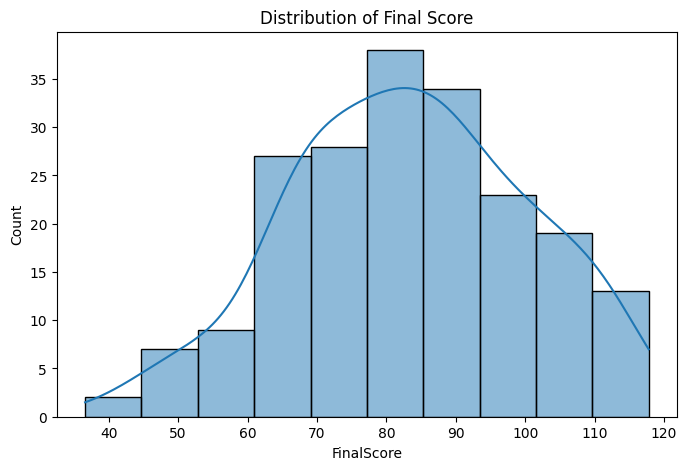

In [152]:
#1. What is the distribution of the target variable (FinalScore)?
plt.figure(figsize=(8,5))
sns.histplot(df['FinalScore'], kde=True)
plt.title('Distribution of Final Score')
plt.show()

 FINAL SCORE DISTRIBUTION
 
 The histogram shows that most students scored within the average to high score range, with fewer extreme values.


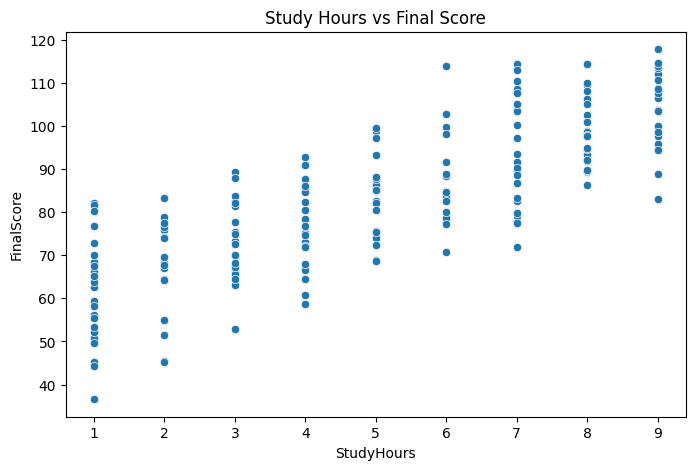

In [153]:
#2. Is there a relationship between StudyHours and FinalScore?
plt.figure(figsize=(8,5))
sns.scatterplot(x='StudyHours', y='FinalScore', data=df)
plt.title('Study Hours vs Final Score')
plt.show()

*GRAPH 2 – STUDY HOURS VS FINAL SCORE**
The scatter plot indicates a positive relationship between study hours and final score, showing that more study time generally improves performance.


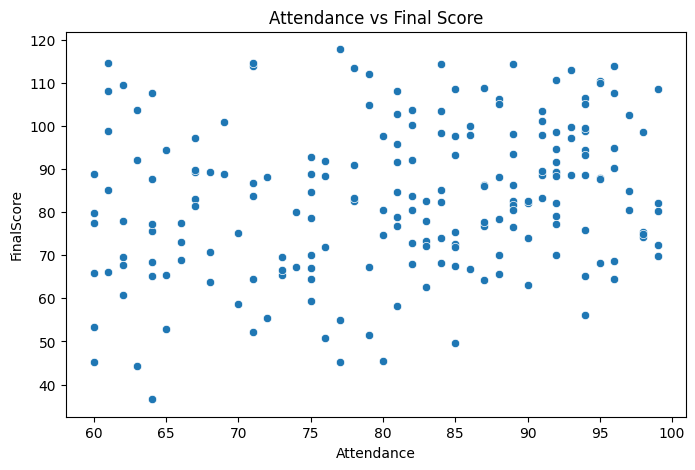

In [154]:
#3. How does Attendance affect FinalScore?
plt.figure(figsize=(8,5))
sns.scatterplot(x='Attendance', y='FinalScore', data=df)
plt.title('Attendance vs Final Score')
plt.show()

GRAPH 3 – ATTENDANCE VS FINAL SCORE
The graph shows that students with higher attendance tend to achieve better final scores.

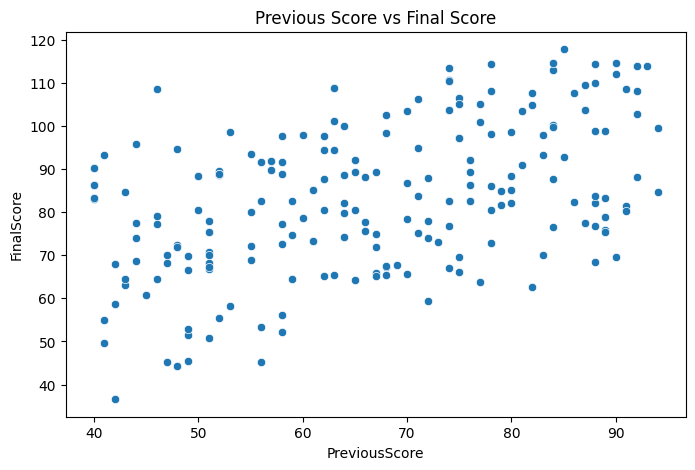

In [155]:
#4. What is the relationship between PreviousScore and FinalScore?
plt.figure(figsize=(8,5))
sns.scatterplot(x='PreviousScore', y='FinalScore', data=df)
plt.title('Previous Score vs Final Score')
plt.show()

GRAPH 4 – PREVIOUS SCORE VS FINAL SCORE**
Students with higher previous scores are more likely to obtain higher final scores in the current evaluation.

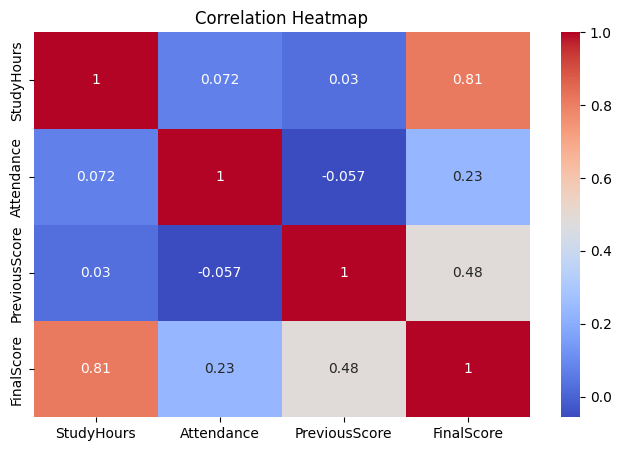

In [156]:
#5. Which features are highly correlated?
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

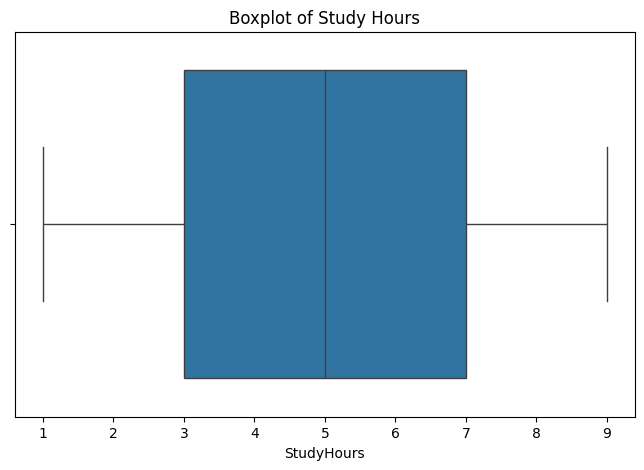

In [157]:
#6. Are there any outliers in StudyHours?
plt.figure(figsize=(8,5))
sns.boxplot(x=df['StudyHours'])
plt.title('Boxplot of Study Hours')
plt.show()

GRAPH 6 – BOXPLOT OF STUDY HOURS**
The boxplot shows the spread of study hours and helps detect any unusual or extreme values in the dataset.


#7. Are there any outliers in Attendance?
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Attendance'])
plt.title('Boxplot of Attendance')
plt.show()

GRAPH 7 – BOXPLOT OF ATTENDANCE**
This boxplot helps identify attendance variations and possible outliers among students.


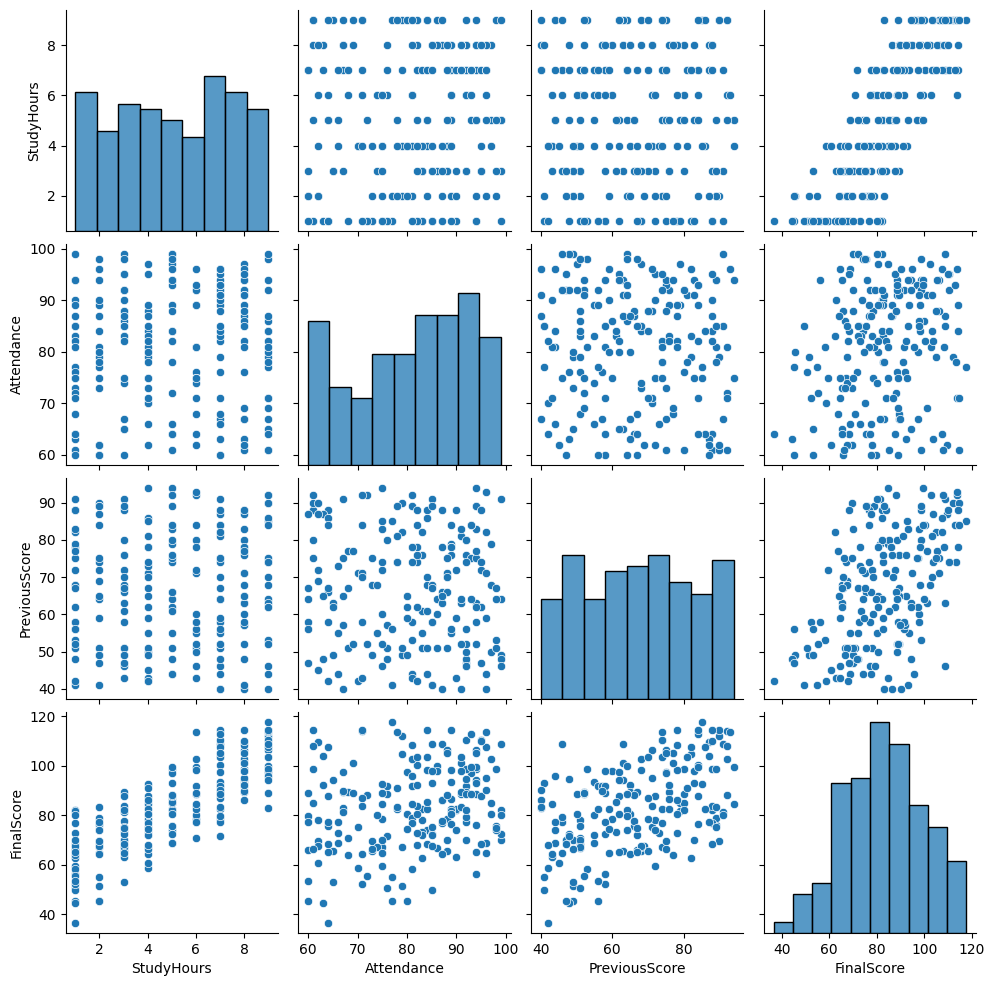

In [158]:
#8. What is the distribution of all numerical features?
sns.pairplot(df)
plt.show()

GRAPH 8 – PAIRPLOT**
The pairplot provides a complete visual understanding of feature distributions and relationships between all variables.


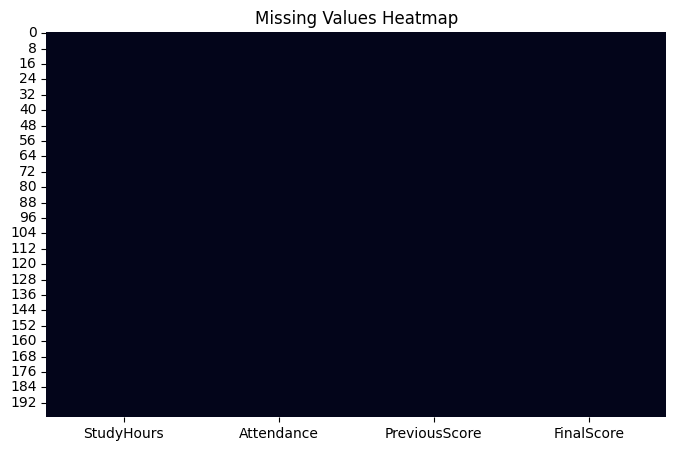

In [159]:
#9. Are there missing values in the dataset?
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

GRAPH 9 – MISSING VALUES HEATMAP**
The heatmap confirms whether the dataset contains missing values that may affect model performance.

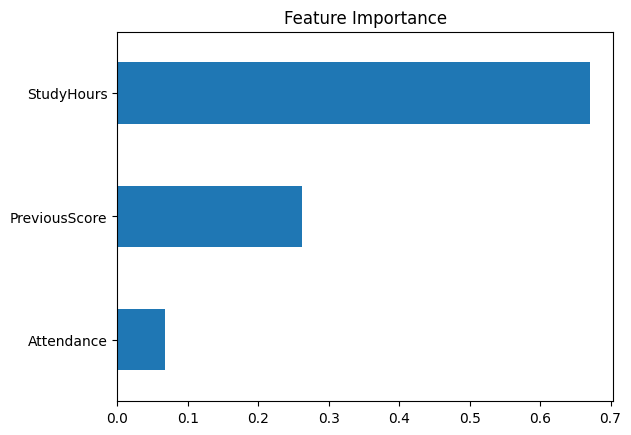

In [160]:
#10. Which feature contributes most to predicting FinalScore?
from sklearn.ensemble import RandomForestRegressor

X = df.drop('FinalScore', axis=1)
y = df['FinalScore']

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

GRAPH 10 – FEATURE IMPORTANCE**
The feature importance graph shows which variables contribute the most to predicting the final score.

<h2 style="font-weight:bold;">7. TRAIN-TEST SPLIT</h2>

<p style="font-size:16px;">
After preprocessing, the dataset is divided into training and testing sets to evaluate model performance. Features (X) and target (y) are separated, and the split is typically done using an 80%-20% ratio.
</p>

<ul style="font-size:16px;">
  <li>Separate features (X) and target (y)</li>
  <li>Split data into training set and testing set</li>
  <li>Ensure random state for reproducibility</li>
  <li>Scaling is applied only after splitting to avoid data leakage</li>
</ul>

In [161]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [162]:
print(x)

[[ 7 60 58]
 [ 4 70 71]
 [ 8 87 40]
 [ 5 84 44]
 [ 7 82 84]
 [ 3 90 43]
 [ 7 89 55]
 [ 8 94 63]
 [ 5 66 55]
 [ 4 75 94]
 [ 8 85 41]
 [ 8 61 88]
 [ 3 60 67]
 [ 6 71 71]
 [ 5 64 66]
 [ 2 96 59]
 [ 8 91 63]
 [ 6 68 51]
 [ 2 94 89]
 [ 5 78 74]
 [ 1 75 72]
 [ 6 62 72]
 [ 9 79 90]
 [ 1 83 82]
 [ 3 92 76]
 [ 7 83 51]
 [ 4 70 42]
 [ 9 67 40]
 [ 3 95 72]
 [ 5 97 79]
 [ 3 99 49]
 [ 7 79 82]
 [ 5 94 83]
 [ 9 84 68]
 [ 7 94 52]
 [ 2 84 51]
 [ 4 88 70]
 [ 9 77 85]
 [ 2 77 41]
 [ 9 61 90]
 [ 5 94 89]
 [ 2 75 74]
 [ 4 95 62]
 [ 7 92 56]
 [ 8 63 65]
 [ 3 92 47]
 [ 1 73 68]
 [ 4 80 65]
 [ 2 79 49]
 [ 8 67 65]
 [ 4 66 73]
 [ 2 62 90]
 [ 6 76 80]
 [ 6 92 46]
 [ 4 71 43]
 [ 6 81 92]
 [ 2 81 89]
 [ 2 89 84]
 [ 4 97 50]
 [ 8 97 68]
 [ 7 67 75]
 [ 9 86 64]
 [ 8 86 60]
 [ 5 93 75]
 [ 2 80 49]
 [ 5 89 76]
 [ 8 92 48]
 [ 9 87 63]
 [ 9 92 74]
 [ 1 64 88]
 [ 9 78 74]
 [ 7 63 87]
 [ 9 94 75]
 [ 8 76 57]
 [ 1 87 88]
 [ 8 89 78]
 [ 8 88 71]
 [ 3 65 63]
 [ 1 94 62]
 [ 8 96 71]
 [ 3 83 76]
 [ 3 88 51]
 [ 1 90 88]
 [ 5

In [163]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


# **MODEL SELECTION**

Model selection is an important step in machine learning where we choose the most suitable algorithm for prediction. Since our target variable **FinalScore** is continuous in nature, regression algorithms are used for prediction.

In this project, we use regression models such as:

- Linear Regression

In [164]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


y_pred` represents the predicted values generated by the machine learning model for the target variable.

After training the model using the training dataset, the model predicts output values for the test dataset using:


In [165]:
y_pred=regressor.predict(x_test)

In [166]:
print("mean_absolute_error:",metrics.mean_absolute_error(y_test,y_pred))
print("mean squared error:",metrics.mean_squared_error(y_test,y_pred))
print("mean:",df.iloc[:,-1].mean())
print("root mean squared error:",np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

mean_absolute_error: 4.363370083715523
mean squared error: 27.249330971988662
mean: 83.17450000000001
root mean squared error: 5.220089172800467


# **R² SCORE**

R² Score is used to measure how well the regression model predicts the target variable. A value closer to 1 indicates better model performance, while a value closer to 0 indicates weaker prediction accuracy.

In [167]:
score=r2_score(y_test,y_pred)
print("r2 score is",score*100,"%")

r2 score is 91.97008274882201 %


# **STANDARD SCALING**

Standard Scaling is used to normalize the data by converting features into a common scale. It helps improve model performance by making the mean equal to 0 and standard deviation equal to 1.





In [168]:

scaler = StandardScaler(with_mean=False)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# **POLYNOMIAL FEATURES**

Polynomial Features are used to create new features by combining existing features with different powers. This helps the model capture non-linear relationships in the dataset.

In [169]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train_scaled)
x_test_poly=poly.transform(x_test_scaled)

In [170]:
model=LinearRegression()
model.fit(x_train_poly,y_train)
y_predicition=model.predict(x_test_poly)

In [171]:
print("mean_absolute_error:",metrics.mean_absolute_error(y_test,y_predicition))
print("mean squared error:",metrics.mean_squared_error(y_test,y_predicition))
print("mean:",df.iloc[:,-1].mean())
print("root mean squared error:",np.sqrt(metrics.mean_squared_error(y_test,y_predicition)))

mean_absolute_error: 4.648266779256539
mean squared error: 31.149681670727126
mean: 83.17450000000001
root mean squared error: 5.5811899869765345


In [172]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_predicition)
print("r2 score is",score*100,"%")

r2 score is 90.82071532421847 %


# **CONCLUSION**

This project successfully demonstrates how machine learning regression techniques can be used to predict student final scores based on important factors such as StudyHours, Attendance, and PreviousScore. Through Exploratory Data Analysis (EDA), meaningful patterns and relationships were identified, helping to understand how each feature influences student performance.

Both Multiple Linear Regression and Polynomial Regression models were applied to the dataset for prediction. The results showed that Multiple Linear Regression achieved an accuracy of approximately 92.7%, while Polynomial Regression achieved around 92.6%, indicating that both models performed very well.

Although the difference in accuracy is very small, Multiple Linear Regression proved to be slightly better due to its simplicity, better interpretability, and strong predictive performance. This project highlights how data analytics and regression models can support academic decision-making and help in pred

In [174]:
new_data = pd.DataFrame({
    'StudyHours': [6],
    'Attendance': [85],
    'PreviousScore': [70]
})

prediction = regressor.predict(new_data)

print("Predicted Final Score:", prediction)


Predicted Final Score: [90.19000019]


c:\Users\sunev\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
